# California Residential Home Price Prediction
# Model Evaluation and Explainability

This notebook evaluates and explains the final XGBoost model from the previous notebook, covering feature importance, SHAP based explanations, price band performance, and practical deployment considerations like model size and prediction latency.

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import shap
import os
import time

## Section 1 - Setup and Loading the Final Model

In [14]:
df_model = pd.read_csv('data/cleaned_data_final.csv')

latest_month = df_model['CloseYear'] * 100 + df_model['CloseMonth']
test_month = latest_month.max()

df_train = df_model[latest_month != test_month].copy()
df_test = df_model[latest_month == test_month].copy()

X_train = df_train.drop(columns=['ClosePrice'])
y_train = df_train['ClosePrice']
X_test = df_test.drop(columns=['ClosePrice'])
y_test = df_test['ClosePrice']

model = xgb.XGBRegressor()
model.load_model('data/xgboost_final_model.json')

y_pred_raw = model.predict(X_test)
y_pred = np.expm1(y_pred_raw)

print('Model loaded and predictions generated.')

Model loaded and predictions generated.


## Section 2 - Confirming Reloaded Model Performance

Quick check that the reloaded model produces the same results as the final version saved in the previous notebook.

In [15]:
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test))

print(f'R2: {r2:.4f}')
print(f'MAPE: {mape:.4f}')
print(f'MdAPE: {mdape:.4f}')

R2: 0.9115
MAPE: 0.1138
MdAPE: 0.0719


## Section 3 - Feature Importance

XGBoost's built in feature importance shows which features the model relies on most, based on how often and how effectively each feature is used to split trees.

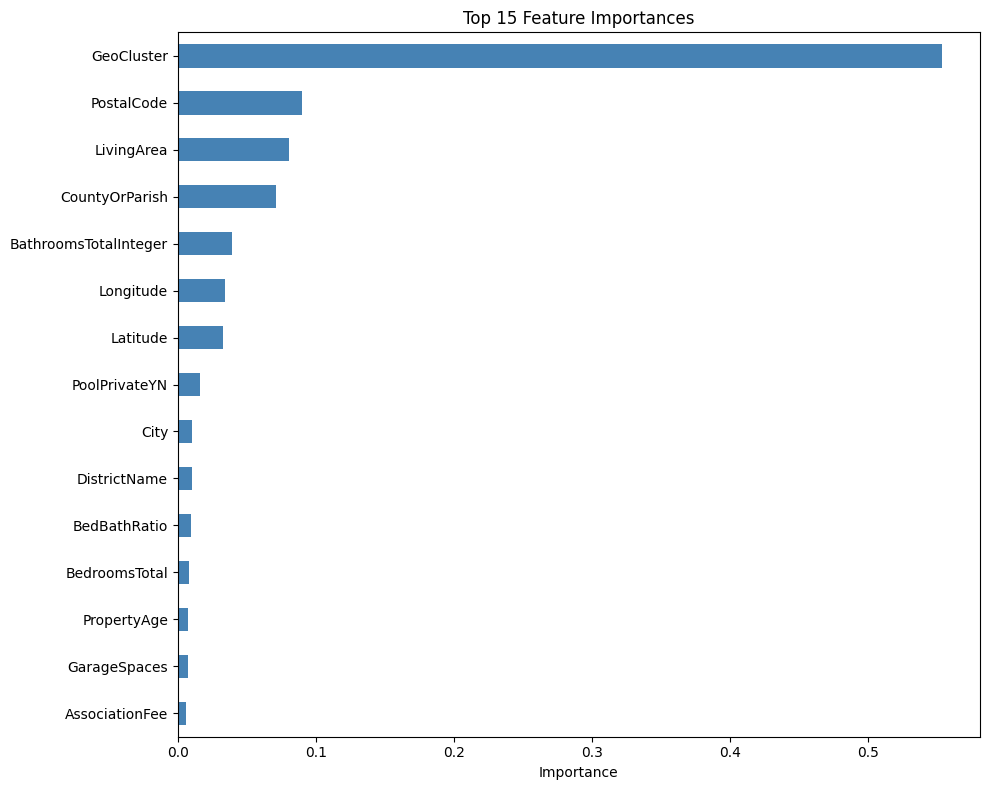

GeoCluster               0.553474
PostalCode               0.089961
LivingArea               0.080794
CountyOrParish           0.071133
BathroomsTotalInteger    0.039304
Longitude                0.034521
Latitude                 0.032497
PoolPrivateYN            0.016119
City                     0.010184
DistrictName             0.009972
BedBathRatio             0.009395
BedroomsTotal            0.007923
PropertyAge              0.007529
GarageSpaces             0.007142
AssociationFee           0.005704
dtype: float32


In [16]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances.head(15))

### Feature Importance Findings

GeoCluster is by far the most important feature in the final model, importance 0.54, over six times higher than the next feature, LivingArea. Location related features overall, GeoCluster, PostalCode, CountyOrParish, Longitude, and Latitude, dominate the top of the importance ranking, directly confirming the early EDA finding that raw property specs show weak correlation with price while location is the dominant driver.

DistrictName, while it provides complete coverage where HighSchoolDistrict was 25 percent missing, ranks relatively low in importance, similar to BedroomsTotal. This suggests that once GeoCluster, PostalCode, and CountyOrParish already capture most location signal, school district adds comparatively little additional predictive power on top of that.

## Section 4 - SHAP Values

While feature importance shows which features matter most overall, SHAP values explain individual predictions, showing exactly how much each feature pushed a specific property's predicted price up or down. This is the level of explainability a real estate agent or buyer would actually want, not just "location matters" but "this specific home's price was pushed up by 45000 dollars because of its location cluster."

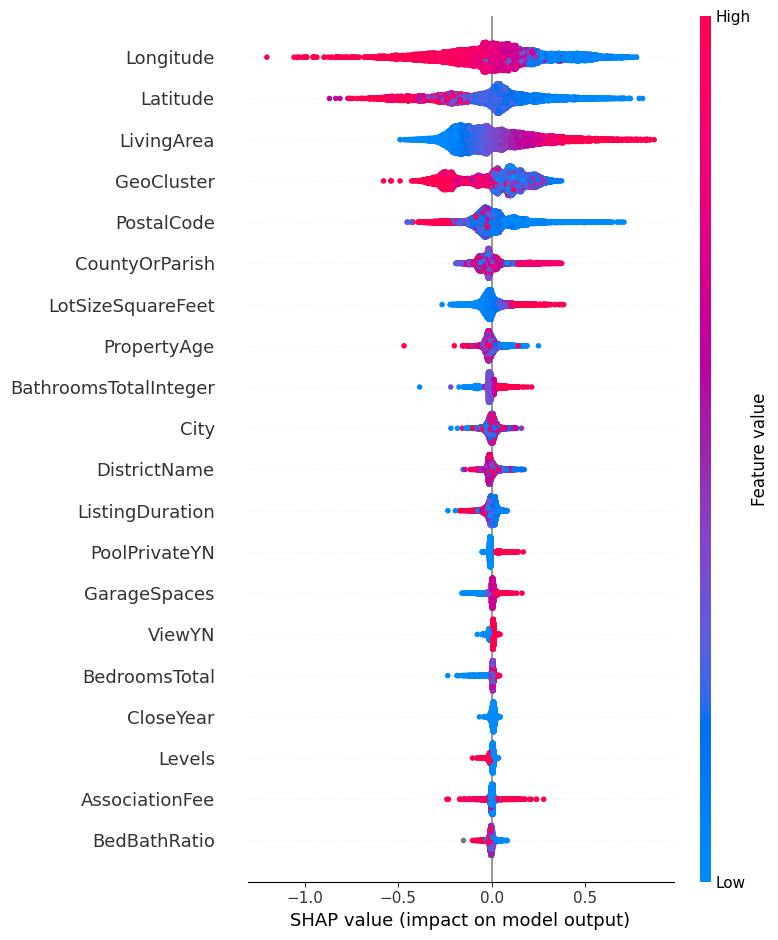

In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png')
plt.show()

### SHAP Findings

SHAP values reveal a nuanced picture that complements the built in feature importance chart. While GeoCluster ranked highest in structural feature importance, SHAP shows Latitude and Longitude have the largest individual impact on specific predictions, with a clear pattern, lower values, corresponding to Southern California and coastal areas, consistently push predicted price up, while higher values push it down.

LivingArea shows the cleanest, most intuitive relationship, larger homes consistently push price up, smaller homes push it down, exactly as expected. GeoCluster's SHAP pattern is more categorical and less continuous than the coordinate features, consistent with it functioning as a location bucket rather than a smooth spatial gradient.

The difference between structural importance and SHAP impact illustrates an important distinction, importance measures how often a feature is used to make decisions, while SHAP measures how much that feature actually moves individual predictions, and the two do not always agree.

## Section 5 - Performance by Price Band

Aggregate metrics can hide important differences across the price spectrum. This section breaks down model accuracy across price tiers to identify where the model performs well and where it struggles.

In [18]:
bands = [0, 500000, 1000000, 2000000, float('inf')]
band_labels = ['Under $500K', '$500K-$1M', '$1M-$2M', '$2M+']

df_test_bands = df_test.copy()
df_test_bands['ActualPrice'] = y_test.values
df_test_bands['PredictedPrice'] = y_pred
df_test_bands['PriceBand'] = pd.cut(df_test_bands['ActualPrice'], bins=bands, labels=band_labels)

df_test_bands['AbsPctError'] = np.abs((df_test_bands['ActualPrice'] - df_test_bands['PredictedPrice']) / df_test_bands['ActualPrice'])

band_summary = df_test_bands.groupby('PriceBand', observed=True).agg(
    count=('ActualPrice', 'count'),
    mdape=('AbsPctError', 'median'),
    mape=('AbsPctError', 'mean')
).reset_index()

print(band_summary)

     PriceBand  count     mdape      mape
0  Under $500K   1813  0.076167  0.189249
1    $500K-$1M   5323  0.057305  0.087339
2      $1M-$2M   3938  0.081391  0.108192
3         $2M+   1513  0.105613  0.130710


### Price Band Findings

Model accuracy varies meaningfully across price tiers. The $500K to $1M band performs best, MdAPE 5.7 percent, while accuracy degrades at both extremes. Luxury properties above $2M show the highest typical error at 10.6 percent MdAPE, nearly double the best performing band, consistent with luxury homes being sparser in the data and more idiosyncratic in pricing. Homes under $500K also show elevated error relative to the middle tier, likely reflecting sparse, rural low cost properties identified during EDA, where fewer comparable sales exist. The gap between MAPE and MdAPE widens somewhat at the top price band, indicating a subset of luxury properties are considerably harder to predict than the typical home in that tier.

## Section 6 - Model Size and Prediction Latency

Since this model is being deployed via Streamlit, practical deployment considerations matter, how large the saved model file is, and how quickly it can generate a single prediction. These directly affect loading time and responsiveness for end users.

In [19]:
model_size_kb = os.path.getsize('data/xgboost_final_model.json') / 1024
print(f'Model file size: {model_size_kb:.1f} KB')

single_row = X_test.iloc[[0]]

start = time.time()
for _ in range(100):
    _ = model.predict(single_row)
end = time.time()

avg_latency_ms = (end - start) / 100 * 1000
print(f'Average prediction latency: {avg_latency_ms:.2f} ms per row')

Model file size: 21605.0 KB
Average prediction latency: 1.18 ms per row


### Model Size and Latency Findings

The final model file is approximately 21.1 MB, and generates a single prediction in about 1 millisecond on average. Both figures are well within practical limits for a responsive, lightweight Streamlit deployment, users will experience effectively instantaneous predictions.

In [20]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('Model saved as pickle.')

Model saved as pickle.
